# Mutual Fund ML Feature Selection — Stage 1

This notebook documents the IC-based feature screening and prepares the next correlation/ML-selection stage.

### Source tables
- `mf200.crisil_fund_monthly_aum_flow_features`
- `mf200.performance_momentum_features`
- `mf200.fund_monthly_outperformance_targets`
- `mf200.nifty500_tri_monthly_benchmark_returns`

### Current workflow
1. Load the all-feature IC results.
2. Apply the `|IC| >= 0.03` screen.
3. Inspect IC stability.
4. Inspect correlation between monthly IC series.
5. Next: calculate correlation on the actual fund-month feature values and then perform ML feature selection using a time-based split.


## 1. Imports and configuration

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

IC_THRESHOLD = 0.03
CORRELATION_THRESHOLD = 0.30
OUTPUT_DIR = Path('feature_selection_output')
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
print('Output directory:', OUTPUT_DIR.resolve())


Output directory: D:\PycharmProjects\mf-ml\feature_selection_output


## 2. Load the IC results

In [2]:
IC_MONTHLY_FILE = Path('ic_monthly_all_features.csv')
IC_SUMMARY_FILE = Path('ic_summary_all_features.csv')

ic_monthly = pd.read_csv(IC_MONTHLY_FILE, parse_dates=['month_date'])
ic_summary = pd.read_csv(IC_SUMMARY_FILE)

ic_summary['abs_mean_ic'] = ic_summary['mean_ic'].abs()
ic_summary['ic_pass'] = np.where(ic_summary['abs_mean_ic'] >= IC_THRESHOLD, 'PASS', 'FAIL')
ic_summary = ic_summary.sort_values('abs_mean_ic', ascending=False).reset_index(drop=True)

print('Monthly IC shape:', ic_monthly.shape)
print('Summary shape:', ic_summary.shape)
display(ic_summary)


Monthly IC shape: (90, 47)
Summary shape: (46, 10)


,predictor,months,mean_ic,median_ic,std_ic,min_ic,max_ic,%_months_abs_ic_ge_0.03,abs_mean_ic,ic_pass
0,t_hml_250,72,0.103544,0.127486,0.408507,-0.818261,0.746992,97.222222,0.103544,PASS
1,t_hml_750,48,0.101490,0.175966,0.338774,-0.749261,0.788538,93.750000,0.101490,PASS
2,t_hml_180,76,0.092070,0.171054,0.425640,-0.836923,0.813168,94.736842,0.092070,PASS
3,sr_p1y,72,0.089367,0.128803,0.312354,-0.693077,0.750435,94.444444,0.089367,PASS
4,ir_p1y,72,0.085239,0.100699,0.307888,-0.639231,0.672174,97.222222,0.085239,PASS
5,ir_p6m,78,0.080901,0.115043,0.318287,-0.651966,0.846154,93.589744,0.080901,PASS
6,monthly_return_percent,88,0.080069,0.056906,0.317205,-0.610686,0.670795,87.500000,0.080069,PASS
7,t_const_180,76,0.075980,0.097808,0.261983,-0.535385,0.611538,92.105263,0.075980,PASS
8,sr_p6m,78,0.074462,0.148378,0.318812,-0.710085,0.860513,97.435897,0.074462,PASS
9,t_const_250,72,0.073902,0.143256,0.267972,-0.511233,0.589610,95.833333,0.073902,PASS


## 3. IC-selected candidate features

In [3]:
ic_selected = ic_summary.loc[ic_summary['ic_pass'].eq('PASS')].copy()
selected_features = ic_selected['predictor'].tolist()

display(ic_selected[['predictor','months','mean_ic','median_ic','std_ic','abs_mean_ic']])
print(f'Number of IC-selected features: {len(selected_features)}')

ic_selected.to_csv(OUTPUT_DIR / 'ic_selected_features.csv', index=False)


,predictor,months,mean_ic,median_ic,std_ic,abs_mean_ic
0,t_hml_250,72,0.103544,0.127486,0.408507,0.103544
1,t_hml_750,48,0.101490,0.175966,0.338774,0.101490
2,t_hml_180,76,0.092070,0.171054,0.425640,0.092070
3,sr_p1y,72,0.089367,0.128803,0.312354,0.089367
4,ir_p1y,72,0.085239,0.100699,0.307888,0.085239
5,ir_p6m,78,0.080901,0.115043,0.318287,0.080901
6,monthly_return_percent,88,0.080069,0.056906,0.317205,0.080069
7,t_const_180,76,0.075980,0.097808,0.261983,0.075980
8,sr_p6m,78,0.074462,0.148378,0.318812,0.074462
9,t_const_250,72,0.073902,0.143256,0.267972,0.073902


Number of IC-selected features: 25


## 4. IC strength and stability

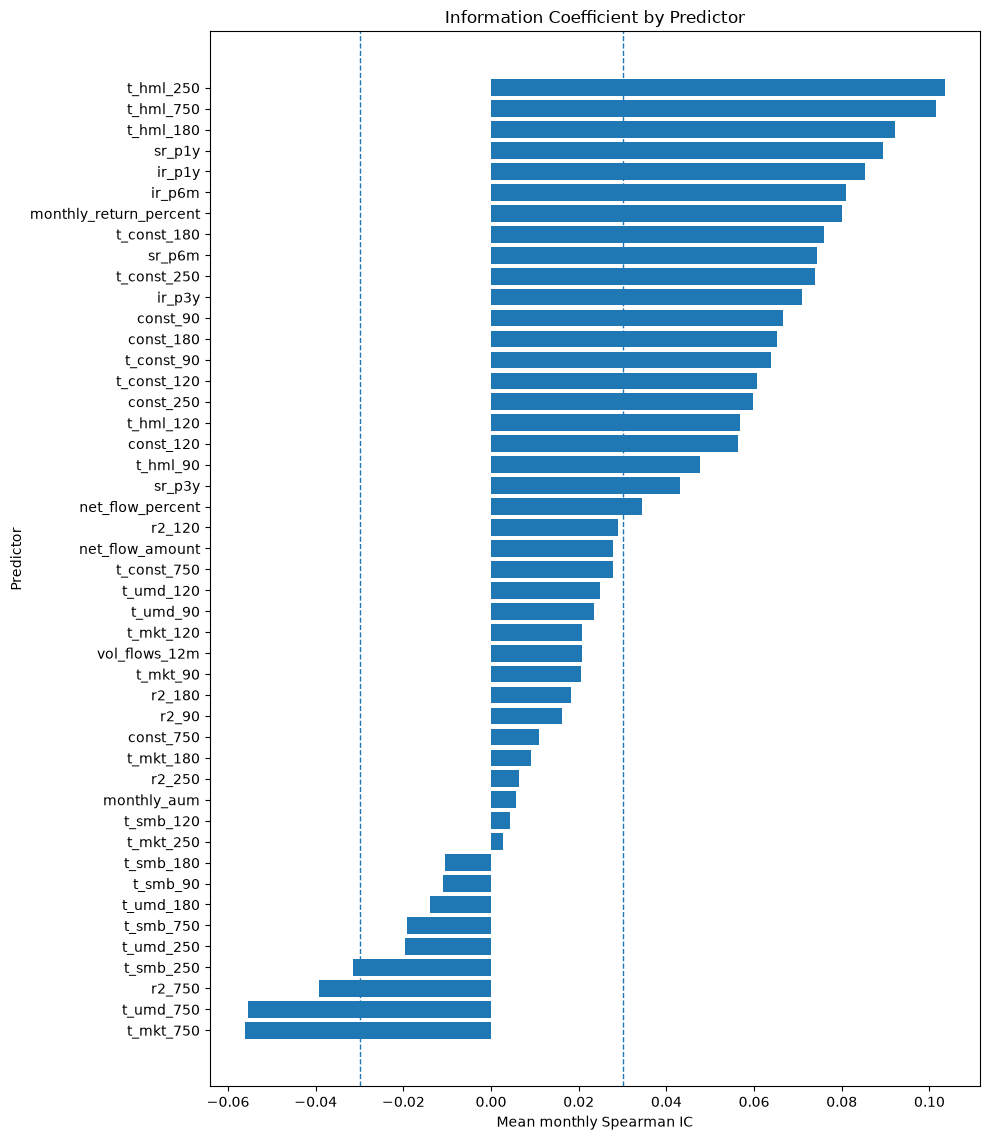

In [4]:
plot_df = ic_summary.sort_values('mean_ic')
plt.figure(figsize=(10, max(6, len(plot_df) * 0.25)))
plt.barh(plot_df['predictor'], plot_df['mean_ic'])
plt.axvline(IC_THRESHOLD, linestyle='--', linewidth=1)
plt.axvline(-IC_THRESHOLD, linestyle='--', linewidth=1)
plt.xlabel('Mean monthly Spearman IC')
plt.ylabel('Predictor')
plt.title('Information Coefficient by Predictor')
plt.tight_layout()
plt.show()


In [5]:
stability = ic_summary[['predictor','months','mean_ic','median_ic','std_ic','%_months_abs_ic_ge_0.03']].copy()
stability['ic_to_volatility'] = (stability['mean_ic'].abs() / stability['std_ic']).replace([np.inf,-np.inf], np.nan)
display(stability.sort_values('ic_to_volatility', ascending=False))


,predictor,months,mean_ic,median_ic,std_ic,%_months_abs_ic_ge_0.03,ic_to_volatility
1,t_hml_750,48,0.101490,0.175966,0.338774,93.750000,0.299580
7,t_const_180,76,0.075980,0.097808,0.261983,92.105263,0.290018
3,sr_p1y,72,0.089367,0.128803,0.312354,94.444444,0.286109
4,ir_p1y,72,0.085239,0.100699,0.307888,97.222222,0.276850
9,t_const_250,72,0.073902,0.143256,0.267972,95.833333,0.275783
18,t_mkt_750,48,-0.056181,-0.061614,0.219562,93.750000,0.255878
13,t_const_90,80,0.063753,0.031770,0.250751,87.500000,0.254251
5,ir_p6m,78,0.080901,0.115043,0.318287,93.589744,0.254177
0,t_hml_250,72,0.103544,0.127486,0.408507,97.222222,0.253469
6,monthly_return_percent,88,0.080069,0.056906,0.317205,87.500000,0.252421


## 5. Correlation diagnostic on monthly IC series

**This is a diagnostic only.** It correlates the predictors' monthly IC series. It is **not** the final pairwise correlation of the underlying fund characteristics. The final 0.30 redundancy test should be calculated on the actual fund-month feature values.


In [6]:
ic_series = ic_monthly.set_index('month_date')[selected_features]
ic_correlation = ic_series.corr(method='spearman')
display(ic_correlation.round(3))
ic_correlation.to_csv(OUTPUT_DIR / 'selected_feature_ic_series_correlation.csv')


,t_hml_250,t_hml_750,t_hml_180,sr_p1y,ir_p1y,ir_p6m,monthly_return_percent,t_const_180,sr_p6m,t_const_250,ir_p3y,const_90,const_180,t_const_90,t_const_120,const_250,t_hml_120,const_120,t_mkt_750,t_umd_750,t_hml_90,sr_p3y,r2_750,net_flow_percent,t_smb_250
t_hml_250,1.000,0.864,0.986,0.107,0.390,0.293,0.114,-0.218,0.021,-0.112,0.544,-0.123,-0.241,-0.089,-0.140,-0.164,0.974,-0.152,0.037,-0.352,0.970,0.393,0.336,0.134,-0.280
t_hml_750,0.864,1.000,0.831,0.542,0.619,0.472,0.113,0.335,0.368,0.318,0.611,0.299,0.295,0.332,0.359,0.302,0.805,0.307,-0.061,-0.454,0.816,0.445,0.254,0.512,-0.184
t_hml_180,0.986,0.831,1.000,0.095,0.387,0.162,0.022,-0.265,-0.076,-0.128,0.514,-0.194,-0.251,-0.179,-0.233,-0.175,0.981,-0.220,-0.004,-0.314,0.974,0.374,0.297,0.076,-0.233
sr_p1y,0.107,0.542,0.095,1.000,0.854,0.648,0.304,0.781,0.756,0.846,0.566,0.646,0.774,0.669,0.730,0.827,0.062,0.696,-0.200,-0.435,0.055,0.609,-0.026,0.713,-0.196
ir_p1y,0.390,0.619,0.387,0.854,1.000,0.737,0.361,0.518,0.671,0.595,0.557,0.523,0.501,0.539,0.500,0.540,0.368,0.473,-0.127,-0.275,0.365,0.526,0.103,0.678,-0.276
ir_p6m,0.293,0.472,0.162,0.648,0.737,1.000,0.570,0.464,0.860,0.417,0.456,0.651,0.454,0.638,0.562,0.370,0.104,0.569,-0.183,-0.145,0.073,0.387,0.005,0.541,-0.244
monthly_return_percent,0.114,0.113,0.022,0.304,0.361,0.570,1.000,0.230,0.473,0.163,0.272,0.326,0.207,0.298,0.240,0.089,-0.036,0.251,-0.185,0.025,-0.057,0.240,-0.150,0.135,-0.319
t_const_180,-0.218,0.335,-0.265,0.781,0.518,0.464,0.230,1.000,0.641,0.915,0.411,0.704,0.972,0.723,0.830,0.924,-0.278,0.812,-0.113,-0.386,-0.280,0.508,-0.020,0.592,-0.125
sr_p6m,0.021,0.368,-0.076,0.756,0.671,0.860,0.473,0.641,1.000,0.592,0.380,0.787,0.649,0.770,0.754,0.594,-0.131,0.774,-0.295,-0.195,-0.160,0.382,-0.144,0.620,-0.098
t_const_250,-0.112,0.318,-0.128,0.846,0.595,0.417,0.163,0.915,0.592,1.000,0.486,0.601,0.876,0.632,0.756,0.975,-0.147,0.716,-0.139,-0.440,-0.136,0.618,-0.035,0.574,-0.228


In [7]:
pairs = []
for i, f1 in enumerate(ic_correlation.columns):
    for f2 in ic_correlation.columns[i+1:]:
        corr = ic_correlation.loc[f1, f2]
        if pd.notna(corr) and abs(corr) > CORRELATION_THRESHOLD:
            pairs.append({'feature_1': f1, 'feature_2': f2, 'correlation': corr, 'abs_correlation': abs(corr)})

correlated_pairs = pd.DataFrame(pairs)
if not correlated_pairs.empty:
    correlated_pairs = correlated_pairs.sort_values('abs_correlation', ascending=False).reset_index(drop=True)
display(correlated_pairs)
correlated_pairs.to_csv(OUTPUT_DIR / 'highly_correlated_ic_series_pairs.csv', index=False)
print(f'Pairs with |correlation| > {CORRELATION_THRESHOLD}: {len(correlated_pairs)}')


,feature_1,feature_2,correlation,abs_correlation
0,t_hml_120,t_hml_90,0.988291,0.988291
1,t_hml_250,t_hml_180,0.985819,0.985819
2,t_hml_180,t_hml_120,0.981271,0.981271
3,t_const_250,const_250,0.975014,0.975014
4,t_hml_250,t_hml_120,0.974436,0.974436
...,...,...,...,...
155,t_hml_180,t_umd_750,-0.314481,0.314481
156,ir_p3y,t_const_90,0.310899,0.310899
157,t_hml_750,const_120,0.306774,0.306774
158,sr_p1y,monthly_return_percent,0.303524,0.303524


Pairs with |correlation| > 0.3: 160


## 6. Fundamental-feature checkpoint

Current fundamental/AUM-flow candidates are `monthly_aum`, `net_flow_percent`, and `vol_flows_12m`.

Do not automatically remove a fundamental category merely because one variable fails the IC screen. We will compare the empirical result with the paper's category-selection rule before the final model specification.


In [8]:
fundamental_features = ['monthly_aum', 'net_flow_percent', 'vol_flows_12m']
fundamental_results = ic_summary[ic_summary['predictor'].isin(fundamental_features)][
    ['predictor','months','mean_ic','median_ic','std_ic','abs_mean_ic','ic_pass']
]
display(fundamental_results)


,predictor,months,mean_ic,median_ic,std_ic,abs_mean_ic,ic_pass
23,net_flow_percent,88,0.034409,0.039273,0.220691,0.034409,PASS
31,vol_flows_12m,77,0.020705,0.005133,0.154288,0.020705,FAIL
43,monthly_aum,89,0.005760,-0.012809,0.192212,0.005760,FAIL


## 7. Next stage

The IC screen is complete. The next notebook stage should:

1. Reconstruct the fund-month feature matrix from the database tables.
2. Keep only the IC-selected candidates.
3. Calculate **pairwise correlation of the actual feature values**.
4. Apply the paper's correlation/redundancy rule carefully.
5. Use a time-ordered training/validation design for ML feature importance.
6. Freeze the selected feature set before evaluating the out-of-sample period.

**Do not delete features automatically from the IC-series correlation output above.**


In [9]:
# ============================================================
# STAGE 2 — BUILD ML DATASET
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

IC_SELECTED_FILE = Path(
    "feature_selection_output/ic_selected_features.csv"
)

ML_OUTPUT_FILE = Path(
    "feature_selection_output/ml_feature_dataset.csv"
)

# ------------------------------------------------------------
# Load IC-selected features
# ------------------------------------------------------------

ic_selected = pd.read_csv(IC_SELECTED_FILE)

selected_features = (
    ic_selected["predictor"]
    .dropna()
    .tolist()
)

print(f"IC-selected features: {len(selected_features)}")
print(selected_features)

IC-selected features: 25
['t_hml_250', 't_hml_750', 't_hml_180', 'sr_p1y', 'ir_p1y', 'ir_p6m', 'monthly_return_percent', 't_const_180', 'sr_p6m', 't_const_250', 'ir_p3y', 'const_90', 'const_180', 't_const_90', 't_const_120', 'const_250', 't_hml_120', 'const_120', 't_mkt_750', 't_umd_750', 't_hml_90', 'sr_p3y', 'r2_750', 'net_flow_percent', 't_smb_250']


In [10]:
# ============================================================
# LOAD FUND-MONTH FEATURES + TARGET
# ============================================================

from sqlalchemy import create_engine, URL
import os

engine = create_engine(
    URL.create(
        "postgresql+psycopg",
        username=os.getenv("DB_USER", "postgres"),
        password=os.getenv("DB_PASSWORD", "Password@123"),
        host=os.getenv("DB_HOST", "localhost"),
        port=int(os.getenv("DB_PORT", "5432")),
        database=os.getenv("DB_NAME", "mfdb"),
    )
)

# ------------------------------------------------------------
# AUM / flow features
# ------------------------------------------------------------

aum_flow = pd.read_sql(
    """
    SELECT
        scheme_name,
        month_date,
        monthly_aum,
        monthly_return_percent,
        net_flow_percent,
        vol_flows_12m
    FROM mf200.crisil_fund_monthly_aum_flow_features
    """,
    engine,
)

# ------------------------------------------------------------
# Momentum features
# ------------------------------------------------------------

momentum = pd.read_sql(
    """
    SELECT *
    FROM mf200.performance_momentum_features
    """,
    engine,
)

momentum["trade_date"] = pd.to_datetime(
    momentum["trade_date"]
)

momentum["month_date"] = (
    momentum["trade_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Keep last observation in each fund/month
momentum = (
    momentum
    .sort_values(
        ["scheme_name", "month_date", "trade_date"]
    )
    .drop_duplicates(
        ["scheme_name", "month_date"],
        keep="last"
    )
)

# ------------------------------------------------------------
# Target
# ------------------------------------------------------------

target = pd.read_sql(
    """
    SELECT
        scheme_name,
        month_date,
        target_month,
        outperforms_benchmark
    FROM mf200.fund_monthly_outperformance_targets
    WHERE benchmark_name = 'Nifty 500 TRI'
      AND outperforms_benchmark IS NOT NULL
    """,
    engine,
)

for df in [aum_flow, target]:
    df["month_date"] = pd.to_datetime(
        df["month_date"]
    )

target["target_month"] = pd.to_datetime(
    target["target_month"]
)

print("AUM/flow rows:", len(aum_flow))
print("Momentum rows:", len(momentum))
print("Target rows:", len(target))

AUM/flow rows: 7324
Momentum rows: 6161
Target rows: 7067


In [11]:
# ============================================================
# COMBINE FEATURES
# ============================================================

# AUM / flow features
feature_df = aum_flow.copy()

# ------------------------------------------------------------
# Add momentum features
# ------------------------------------------------------------

momentum_feature_columns = [
    c for c in selected_features
    if c in momentum.columns
]

momentum_keep = [
    "scheme_name",
    "month_date",
] + momentum_feature_columns

momentum_small = momentum[momentum_keep].copy()

feature_df = feature_df.merge(
    momentum_small,
    on=["scheme_name", "month_date"],
    how="outer",
    validate="one_to_one",
)

# ------------------------------------------------------------
# Keep only features that survived IC selection
# ------------------------------------------------------------

available_features = [
    f for f in selected_features
    if f in feature_df.columns
]

missing_features = [
    f for f in selected_features
    if f not in feature_df.columns
]

print("Available selected features:", len(available_features))

if missing_features:
    print(
        "WARNING — missing features:",
        missing_features
    )

# ------------------------------------------------------------
# Join target
# ------------------------------------------------------------

target_small = target[
    [
        "scheme_name",
        "month_date",
        "target_month",
        "outperforms_benchmark",
    ]
].copy()

ml_df = feature_df.merge(
    target_small,
    on=["scheme_name", "month_date"],
    how="inner",
    validate="one_to_one",
)

print("ML dataset rows:", len(ml_df))

Available selected features: 25
ML dataset rows: 7034


In [12]:
# ============================================================
# DATASET VALIDATION
# ============================================================

print("\n========== DATE RANGE ==========")

print(
    "Feature month:",
    ml_df["month_date"].min(),
    "to",
    ml_df["month_date"].max()
)

print(
    "Target month:",
    ml_df["target_month"].min(),
    "to",
    ml_df["target_month"].max()
)

print("\n========== FUND COVERAGE ==========")

print(
    "Unique funds:",
    ml_df["scheme_name"].nunique()
)

print(
    "Unique feature months:",
    ml_df["month_date"].nunique()
)

print("\n========== TARGET ==========")

print(
    ml_df["outperforms_benchmark"].value_counts(
        dropna=False
    )
)

print("\n========== DUPLICATES ==========")

duplicates = ml_df.duplicated(
    ["scheme_name", "month_date"]
).sum()

print(
    "Fund/month duplicates:",
    duplicates
)

print("\n========== MISSING FEATURES ==========")

missing = (
    ml_df[available_features]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

display(
    missing.to_frame("missing_fraction")
)

print("\n========== SAMPLE ==========")

display(
    ml_df[
        [
            "scheme_name",
            "month_date",
            "target_month",
            "outperforms_benchmark",
        ] + available_features
    ].head()
)


========== DATE RANGE ==========
Feature month: 2019-01-01 00:00:00 to 2026-06-01 00:00:00
Target month: 2019-02-01 00:00:00 to 2026-07-01 00:00:00

========== FUND COVERAGE ==========
Unique funds: 160
Unique feature months: 90

========== TARGET ==========
outperforms_benchmark
1    3614
0    3420
Name: count, dtype: int64

========== DUPLICATES ==========
Fund/month duplicates: 0

========== MISSING FEATURES ==========


,missing_fraction
t_hml_750,0.716804
t_mkt_750,0.716804
t_umd_750,0.716804
r2_750,0.716804
sr_p3y,0.716804
ir_p3y,0.716804
t_hml_250,0.372192
ir_p1y,0.372192
sr_p1y,0.372192
const_250,0.372192



========== SAMPLE ==========


,scheme_name,month_date,target_month,outperforms_benchmark,t_hml_250,t_hml_750,t_hml_180,sr_p1y,ir_p1y,ir_p6m,monthly_return_percent,t_const_180,sr_p6m,t_const_250,ir_p3y,const_90,const_180,t_const_90,t_const_120,const_250,t_hml_120,const_120,t_mkt_750,t_umd_750,t_hml_90,sr_p3y,r2_750,net_flow_percent,t_smb_250
0,Aditya Birla Sun Life Dividend Yield Fund,2022-01-01,2022-02-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aditya Birla Sun Life Dividend Yield Fund,2022-02-01,2022-03-01,1,NaN,NaN,NaN,NaN,NaN,NaN,-3.467324,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.409967,NaN
2,Aditya Birla Sun Life Dividend Yield Fund,2022-03-01,2022-04-01,0,NaN,NaN,NaN,NaN,NaN,NaN,5.231209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.817055,NaN
3,Aditya Birla Sun Life Dividend Yield Fund,2022-04-01,2022-05-01,1,NaN,NaN,NaN,NaN,NaN,NaN,-2.814417,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.541675,NaN
4,Aditya Birla Sun Life Dividend Yield Fund,2022-05-01,2022-06-01,0,NaN,NaN,NaN,NaN,NaN,NaN,-3.738989,NaN,NaN,NaN,NaN,-0.000255,NaN,-0.648574,NaN,NaN,NaN,NaN,NaN,NaN,4.072015,NaN,NaN,-0.119226,NaN


In [13]:
# ============================================================
# FINAL ML DATASET
# ============================================================

ml_final = ml_df[
    [
        "scheme_name",
        "month_date",
        "target_month",
        "outperforms_benchmark",
    ] + available_features
].copy()

# Sort chronologically
ml_final = ml_final.sort_values(
    ["month_date", "scheme_name"]
).reset_index(drop=True)

# Save
ml_final.to_csv(
    ML_OUTPUT_FILE,
    index=False
)

print(
    f"Saved ML dataset to: {ML_OUTPUT_FILE}"
)

print(
    "Shape:",
    ml_final.shape
)

Saved ML dataset to: feature_selection_output\ml_feature_dataset.csv
Shape: (7034, 29)


In [17]:
check = ml_final[
    ["month_date", "target_month"]
].drop_duplicates()

check["month_diff"] = (
    check["target_month"].dt.to_period("M")
    -
    check["month_date"].dt.to_period("M")
)

display(check["month_diff"].value_counts())

print(ml_final["outperforms_benchmark"].value_counts(normalize=True))

month_diff
<MonthEnd>    90
Name: count, dtype: int64

outperforms_benchmark
1    0.51379
0    0.48621
Name: proportion, dtype: float64


In [18]:
check = ml_final[
    ["month_date", "target_month"]
].drop_duplicates()

check["month_diff"] = (
    check["target_month"].dt.to_period("M").astype(int)
    - check["month_date"].dt.to_period("M").astype(int)
)

print(check["month_diff"].value_counts().sort_index())

month_diff
1    90
Name: count, dtype: int64
